In [1]:
import numpy as np
import pandas as pd
import sqlite3

# 1. Đọc dữ liệu từ file train gốc của ba
df = pd.read_csv('train.csv')
df.columns = df.columns.str.strip().str.replace(' ', '_')

# 2. Drop các cột không dùng và cột thiếu nhiều (~40%)
df_cleaned = df.drop(columns=["Address", "Propertycount", "Method", "SellerG", "Postcode", "CouncilArea"], errors='ignore')
df_cleaned = df_cleaned.drop(columns=["BuildingArea", "YearBuilt"], errors='ignore')
df_cleaned = df_cleaned.dropna() 

# 3. Lọc dữ liệu bất hợp lý và trùng lặp
for col in ["Rooms", "Price", "Landsize"]:
    if col in df_cleaned.columns:
        df_cleaned = df_cleaned[df_cleaned[col] > 0]
df_cleaned = df_cleaned.drop_duplicates()

# 4. Ép kiểu dữ liệu và trích xuất thời gian
int_cols = ["Rooms", "Bedroom2", "Bathroom", "Car"]
for col in int_cols:
    df_cleaned[col] = df_cleaned[col].astype(int)

df_cleaned["Date"] = pd.to_datetime(df_cleaned["Date"], dayfirst=True)
df_cleaned["year"] = df_cleaned["Date"].dt.year
df_cleaned["month"] = df_cleaned["Date"].dt.month

# 5. Xử lý gom nhóm Suburb hiếm giao dịch thành 'Other'
Suburb_stats = df_cleaned['Suburb'].value_counts()
Suburb_stats_less_than_10 = Suburb_stats[Suburb_stats <= 10]
df_cleaned['Suburb'] = df_cleaned['Suburb'].apply(lambda x: 'Other' if x in Suburb_stats_less_than_10 else x)

# 6. Lọc bỏ các vùng miền hiếm giao dịch
dropped_region = ['Eastern Victoria', 'Northern Victoria', 'Western Victoria']
df_cleaned = df_cleaned[~df_cleaned['Regionname'].isin(dropped_region)]

# ==============================================================================
# ĐIỂM QUAN TRỌNG: Giữ lại cột Type và Regionname gốc để phục vụ phân tích SQL
# ==============================================================================
# Tạo bản sao lưu dummy nhưng KHÔNG xóa cột gốc
dummy_type = pd.get_dummies(df_cleaned["Type"], dtype=int).rename(columns={'h':'Type_h', 't':'Type_t', 'u':'Type_u'})
dummy_region = pd.get_dummies(df_cleaned["Regionname"], dtype=int).rename(columns={
    'Northern Metropolitan': 'Region_NM', 'Western Metropolitan': 'Region_WM',
    'Southern Metropolitan': 'Region_SM', 'Eastern Metropolitan': 'Region_EM',
    'South-Eastern Metropolitan': 'Region_SEM'
})
df_cleaned = pd.concat([df_cleaned, dummy_type, dummy_region], axis=1)

# 7. Kết nối và đẩy vào SQLite
conn = sqlite3.connect("melb_real_estate.db")
conn.execute("PRAGMA synchronous = OFF")
conn.execute("PRAGMA journal_mode = MEMORY")
df_cleaned.to_sql("melb_real_estate", conn, if_exists="replace", index=False)

print(f"Bảng 'melb_real_estate' đã sẵn sàng phục vụ phân tích SQL với {df_cleaned.shape[0]} dòng!")
df.info()

Bảng 'melb_real_estate' đã sẵn sàng phục vụ phân tích SQL với 15468 dòng!
<class 'pandas.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         34857 non-null  str    
 1   Address        34857 non-null  str    
 2   Rooms          34857 non-null  int64  
 3   Type           34857 non-null  str    
 4   Price          27247 non-null  float64
 5   Method         34857 non-null  str    
 6   SellerG        34857 non-null  str    
 7   Date           34857 non-null  str    
 8   Distance       34856 non-null  float64
 9   Postcode       34856 non-null  float64
 10  Bedroom2       26640 non-null  float64
 11  Bathroom       26631 non-null  float64
 12  Car            26129 non-null  float64
 13  Landsize       23047 non-null  float64
 14  BuildingArea   13742 non-null  float64
 15  YearBuilt      15551 non-null  float64
 16  CouncilArea    34854 non-null  


📊 Trung bình Price theo loại hình BĐS
  Type     avg_Price
0    u  6.391677e+05
1    t  9.516902e+05
2    h  1.235505e+06


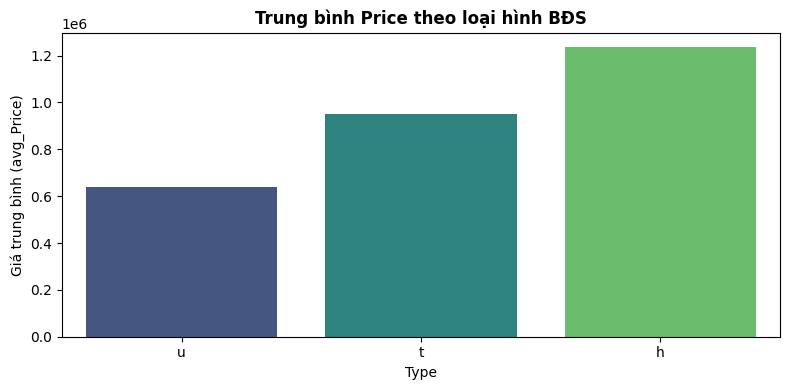


📊 Trung bình Price theo số lượng phòng
   Rooms     avg_Price
0      1  5.216496e+05
1      2  8.647569e+05
2      3  1.065163e+06
3      4  1.408955e+06
4      5  1.871346e+06


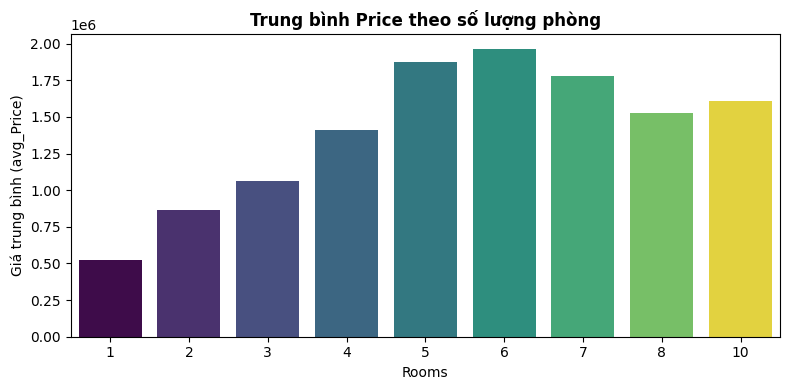


📊 Trung bình Price theo Region
                   Regionname     avg_Price
0       Southern Metropolitan  1.644684e+06
1        Eastern Metropolitan  1.146424e+06
2       Northern Metropolitan  9.330858e+05
3  South-Eastern Metropolitan  9.289621e+05
4        Western Metropolitan  8.990419e+05


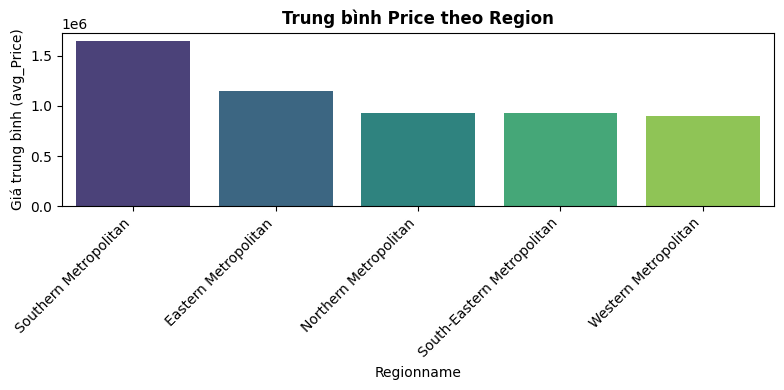


📊 Trung bình Price theo 20 Suburb đầu tiên
        Suburb     avg_Price
0      Malvern  2.563368e+06
1  Middle Park  2.486769e+06
2   Canterbury  2.392750e+06
3     Brighton  2.269978e+06
4       Toorak  2.261080e+06


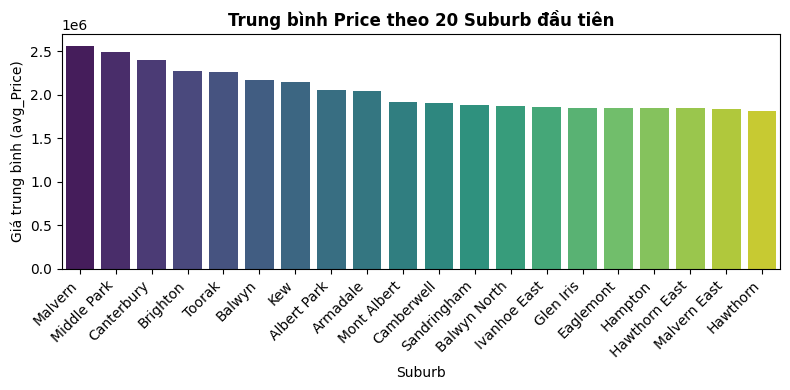


📊 Mối quan hệ giữa giá cả và diện tích
   Landsize      Price
0     202.0  1480000.0
1     156.0  1035000.0
2     134.0  1465000.0
3      94.0   850000.0
4     120.0  1600000.0


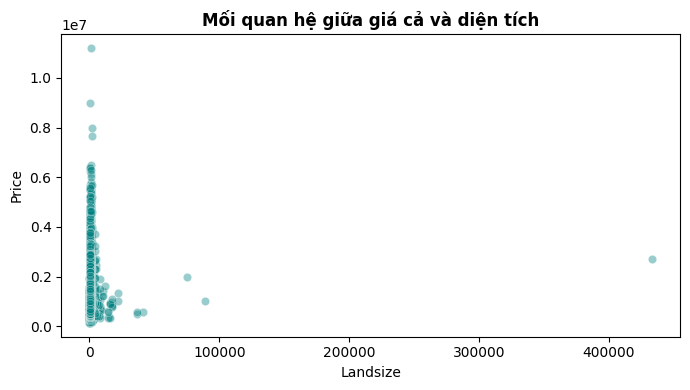


📊 Mối quan hệ giữa giá trung bình và khoảng cách trung bình đến CBD, GROUP BY Suburb
   avg_Distance     avg_Price
0      2.680000  1.175610e+06
1      8.419149  1.484489e+06
2     11.800000  7.903548e+05
3      3.210448  2.049015e+06
4     12.597872  6.255532e+05


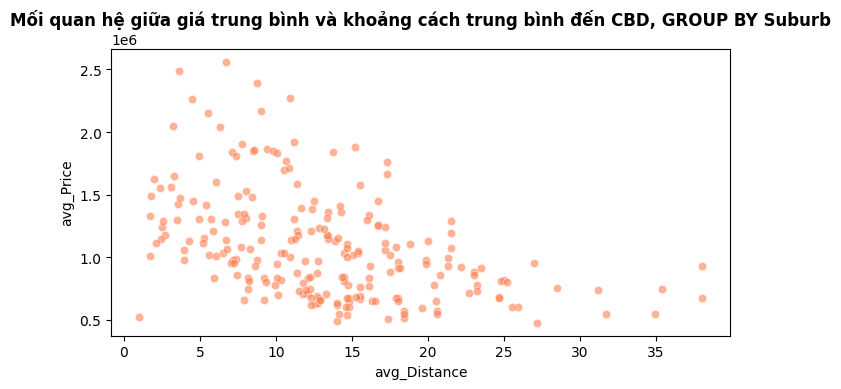


[HOÀN THÀNH] Đã phân tích xong dữ liệu bằng SQL và đóng kết nối an toàn.


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# 3. Danh sách các truy vấn quan trọng của ba (Đã thêm LIMIT 20 để biểu đồ Suburb không bị nghẽn)
queries = {
    "Trung bình Price theo loại hình BĐS": """
        SELECT Type, AVG(Price) AS avg_Price
        FROM melb_real_estate
        GROUP BY Type
        ORDER BY AVG(Price);
    """,
    "Trung bình Price theo số lượng phòng": """
        SELECT Rooms, AVG(Price) AS avg_Price
        FROM melb_real_estate
        GROUP BY Rooms
        ORDER BY Rooms;
    """,
    "Trung bình Price theo Region": """
        SELECT Regionname, AVG(Price) AS avg_Price
        FROM melb_real_estate
        GROUP BY Regionname
        ORDER BY AVG(Price) DESC;
    """,
    "Trung bình Price theo 20 Suburb đầu tiên": """
        SELECT Suburb, AVG(Price) AS avg_Price
        FROM melb_real_estate
        GROUP BY Suburb
        ORDER BY AVG(Price) DESC
        LIMIT 20;
    """,
    "Mối quan hệ giữa giá cả và diện tích": """
        SELECT Landsize, Price
        FROM melb_real_estate
    """,
    "Mối quan hệ giữa giá trung bình và khoảng cách trung bình đến CBD, GROUP BY Suburb": """
        SELECT AVG(Distance) as avg_Distance, AVG(Price) AS avg_Price
        FROM melb_real_estate
        GROUP BY Suburb
    """
}

# 4. Thực thi truy vấn và trực quan hóa tự động
for title, query in queries.items():
    df_query = pd.read_sql(query, conn)
    print(f"\n📊 {title}")
    print(df_query.head())
    
    cols = df_query.columns.tolist()

    # Dạng 1: Biểu đồ cột (Barplot) cho các phân tích so sánh giá trung bình
    if "avg_Price" in cols and len(cols) == 2 and "avg_Distance" not in cols:
        plt.figure(figsize=(8, 4))
        sns.barplot(data=df_query, x=cols[0], y=cols[1], hue=cols[0], palette="viridis", legend=False)
        plt.title(title, fontweight='bold', fontsize=12)
        plt.xlabel(cols[0])
        plt.ylabel("Giá trung bình (avg_Price)")
        
        if cols[0] in ["Regionname", "Suburb"]:
            plt.xticks(rotation=45, ha='right')
            
        plt.tight_layout()
        plt.show()
        
    # Dạng 2: Biểu đồ phân tán (Scatterplot) giữa Diện tích và Giá nhà
    elif "Landsize" in cols and "Price" in cols:
        plt.figure(figsize=(7, 4))
        sns.scatterplot(data=df_query, x="Landsize", y="Price", alpha=0.4, color="teal")
        plt.title(title, fontweight='bold', fontsize=12)
        plt.xlabel("Landsize")
        plt.ylabel("Price")
        plt.tight_layout()
        plt.show()
        
    # Dạng 3: Biểu đồ phân tán (Scatterplot) giữa Khoảng cách và Giá trung bình theo khu vực
    elif "avg_Distance" in cols and "avg_Price" in cols:
        plt.figure(figsize=(7, 4))
        sns.scatterplot(data=df_query, x="avg_Distance", y="avg_Price", alpha=0.6, color="coral")
        plt.title(title, fontweight='bold', fontsize=12)
        plt.xlabel("avg_Distance")
        plt.ylabel("avg_Price")
        plt.tight_layout()
        plt.show()

# Đóng kết nối an toàn sau khi hoàn tất toàn bộ tệp phân tích
conn.close()
print("\n[HOÀN THÀNH] Đã phân tích xong dữ liệu bằng SQL và đóng kết nối an toàn.")

## Nhận xét Chuyên sâu từ Kết quả Truy vấn SQL:

Dựa vào các biểu đồ trực quan hóa từ truy vấn SQL, chúng ta có thể rút ra các kết luận quan trọng sau để phục vụ cho việc xây dựng mô hình dự đoán:

* **Loại hình BĐS (Type) & Số phòng (Rooms):** Giá nhà có xu hướng tăng dần từ `u` (Unit) -> `t` (Townhouse) -> `h` (House). Sự khác biệt này phản ánh giá trị của quyền sở hữu đất đai đi kèm. Bên cạnh đó, số lượng phòng (`Rooms`) có mối quan hệ đồng biến tỷ lệ thuận rất đều với giá nhà, cho thấy đây là biến định lượng cốt lõi cần giữ lại.
* **Yếu tố Vị trí (Regionname & Suburb):** Yếu tố địa lý quyết định phần lớn giá trị BĐS. Khu vực **Southern Metropolitan** có giá trung bình cao vượt trội vượt bậc. Khi chi tiết hóa theo `Suburb`, giá cả có sự phân hóa mạnh mẽ và rõ rệt giữa các khu vực. Điều này khẳng định giả thuyết: *Giá nhà phụ thuộc rất lớn vào vị trí địa lý (Suburb)*.
* **Diện tích đất (Landsize):** Biểu đồ phân tán cho thấy mối quan hệ giữa diện tích và giá cả là **phi tuyến tính (Non-linear)** với độ phân tán cực kỳ cao. Những căn nhà diện tích nhỏ tại trung tâm vẫn có giá cao hơn nhà diện tích lớn ở vùng ven, cho thấy biến này cần một mô hình phi tuyến tính mạnh như Random Forest để xử lý.
* **Khoảng cách đến trung tâm (Distance):** Xu hướng giảm giá khi khoảng cách đến CBD tăng lên là khá rõ rệt (quan hệ nghịch biến). Tuy nhiên, biên độ dao động lớn tại mỗi mốc khoảng cách chứng tỏ có các yếu tố tiện ích cục bộ (trường học, bờ biển, giao thông) tác động thêm vào giá trị của từng Suburb.